# Descriptive Data Mining — Disaster Response Dataset

Techniques applied (IS-212 Data and Knowledge Mining):

| Section | Technique | Topic |
|---------|-----------|-------|
| 1 | KDD Process · Data Preparation | Topic 1 |
| 2 | Frequent Pattern Mining · Association Rules | Topic 2 |
| 3 | Cluster Analysis (K-Means, Hierarchical, DBSCAN) | Topic 4 |
| 4 | Cluster Visualisation & Interpretation | Topic 4 |
| 5 | Extended EDA | — |


---
## 0 · Setup

In [1]:
import re, warnings, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from pathlib import Path
from wordcloud import WordCloud, STOPWORDS

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import normalize
from mlxtend.frequent_patterns import apriori, association_rules

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13,
                     "axes.labelsize": 11, "xtick.labelsize": 9, "ytick.labelsize": 9})

ROOT     = Path("..").resolve()
DATA_DIR = ROOT / "data"
OUT_DIR  = ROOT / "outputs"
OUT_DIR.mkdir(exist_ok=True)

print(f"ROOT → {ROOT}")


ROOT → /Users/waiyantun/PycharmProjects/kiro-datamining


---
## 1 · KDD Process — Data Preparation

> *"Data cleaning, integration, transformation, and selection are essential steps
> before data mining can begin."* — Topic 1


In [2]:
# ── helpers ──────────────────────────────────────────────────────────────
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    return re.sub(r"\s+", " ", text).strip()

def parse_categories(cat_series):
    split = cat_series.str.split(";", expand=True)
    col_names = split.iloc[0].apply(lambda x: x.rsplit("-", 1)[0])
    split.columns = col_names
    for col in split.columns:
        split[col] = split[col].apply(
            lambda x: int(str(x).rsplit("-", 1)[-1])).clip(0, 1)
    return split.astype(np.int8)

# ── load & merge ──────────────────────────────────────────────────────────
messages   = pd.read_csv(DATA_DIR / "disaster_messages.csv")
categories = pd.read_csv(DATA_DIR / "disaster_categories.csv")

df = messages.merge(categories, on="id")
df = df.drop_duplicates(subset="id").reset_index(drop=True)

cat_df = parse_categories(df["categories"])
df = pd.concat([df.drop(columns=["categories"]), cat_df], axis=1)
df["message_clean"] = df["message"].apply(clean_text)
df["msg_len"]       = df["message_clean"].str.len()

# ── category lists ─────────────────────────────────────────────────────────
NOISE_COLS = {"related","request","offer","direct_report","child_alone","tools","shops"}
all_cats   = [c for c in cat_df.columns if c not in NOISE_COLS]

# ── urgency labels ─────────────────────────────────────────────────────────
URGENCY_WEIGHTS = {
    "death":4,"medical_help":3,"medical_products":3,
    "search_and_rescue":3,"missing_people":3,
    "water":2,"food":2,"shelter":2,"floods":2,"earthquake":2,
    "storm":2,"fire":2,"infrastructure_related":1,"transport":1,
    "buildings":1,"electricity":1,"other_aid":1,"refugees":1,"direct_report":1,
}
URGENCY_THRESHOLDS = {0:0, 1:1, 4:2, 7:3}
URGENCY_NAMES      = {0:"low", 1:"medium", 2:"high", 3:"critical"}

def _score_to_level(s):
    lvl = 0
    for t, l in sorted(URGENCY_THRESHOLDS.items()):
        if s >= t: lvl = l
    return lvl

df["urgency_score"] = sum(
    df.get(c, 0) * w for c, w in URGENCY_WEIGHTS.items() if c in df.columns)
df["urgency_level"] = df["urgency_score"].apply(_score_to_level)
df["urgency_label"] = df["urgency_level"].map(URGENCY_NAMES)
df["label_count"]   = df[all_cats].sum(axis=1)

meaningful = [c for c in all_cats]
df["is_disaster"] = (
    (df["related"] == 1) & (df[meaningful].sum(axis=1) >= 1)).astype(int)

print(f"Shape : {df.shape}")
print(f"Messages : {len(df):,}")
print(f"Useful categories : {len(all_cats)}")
print(f"Mean msg length   : {df['msg_len'].mean():.0f} chars")
print(f"Mean label count  : {df['label_count'].mean():.2f}")
df.head(3)


Shape : (26180, 47)
Messages : 26,180
Useful categories : 29
Mean msg length   : 140 chars
Mean label count  : 2.03


,id,message,original,genre,related,request,offer,aid_related,medical_help,medical_products,...,cold,other_weather,direct_report,message_clean,msg_len,urgency_score,urgency_level,urgency_label,label_count,is_disaster
0,2,Weather update - a cold front from Cuba that c...,Un front froid se retrouve sur Cuba ce matin. ...,direct,1,0,0,0,0,0,...,0,0,0,weather update a cold front from cuba that cou...,64,0,0,low,0,0
1,7,Is the Hurricane over or is it not over,Cyclone nan fini osinon li pa fini,direct,1,0,0,1,0,0,...,0,0,0,is the hurricane over or is it not over,39,3,1,medium,4,1
2,8,Looking for someone but no name,"Patnm, di Maryani relem pou li banm nouvel li ...",direct,1,0,0,0,0,0,...,0,0,0,looking for someone but no name,31,0,0,low,0,0


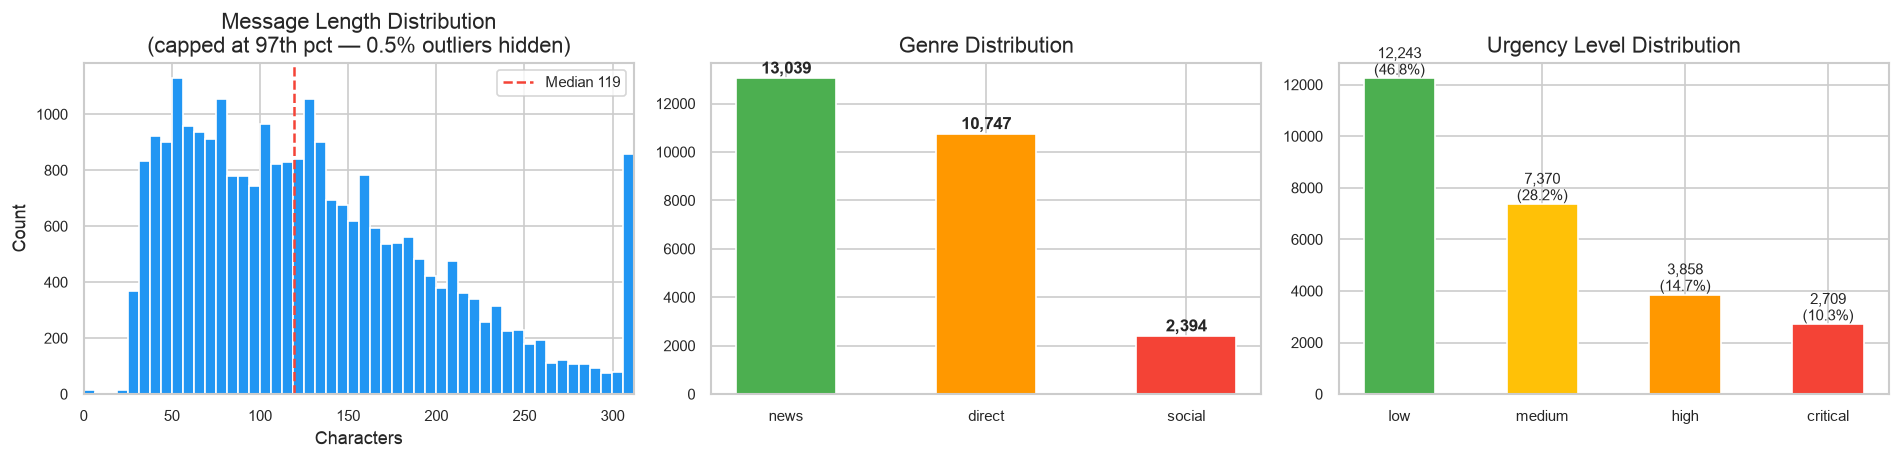

In [3]:
# ── Data overview: message length · genre · urgency ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Message length — cap at 97th percentile to remove long-tail whitespace
x_cap = int(np.percentile(df["msg_len"], 97))   # ~312 chars
plot_data = df["msg_len"].clip(upper=x_cap)
axes[0].hist(plot_data, bins=50, color="#2196F3", edgecolor="white", range=(0, x_cap))
axes[0].set_xlim(0, x_cap)
axes[0].set_title("Message Length Distribution\n(capped at 97th pct — 0.5% outliers hidden)")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Count")
axes[0].axvline(df["msg_len"].median(), color="#F44336", linewidth=1.5,
                linestyle="--", label=f"Median {df['msg_len'].median():.0f}")
axes[0].legend(fontsize=9)

# Genre
gc = df["genre"].value_counts()
axes[1].bar(gc.index, gc.values,
            color=["#4CAF50","#FF9800","#F44336"], edgecolor="white", width=0.5)
axes[1].set_title("Genre Distribution")
for i, v in enumerate(gc.values):
    axes[1].text(i, v + 200, f"{v:,}", ha="center", fontsize=10, fontweight="bold")

# Urgency
urg_order  = ["low","medium","high","critical"]
urg_colors = ["#4CAF50","#FFC107","#FF9800","#F44336"]
urg_counts = df["urgency_label"].value_counts().reindex(urg_order)
axes[2].bar(urg_order, urg_counts.values, color=urg_colors, edgecolor="white", width=0.5)
axes[2].set_title("Urgency Level Distribution")
for i, v in enumerate(urg_counts.values):
    axes[2].text(i, v + 150, f"{v:,}\n({v/len(df)*100:.1f}%)",
                 ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / "overview_length_genre_urgency.png", dpi=150, bbox_inches="tight")
plt.show()


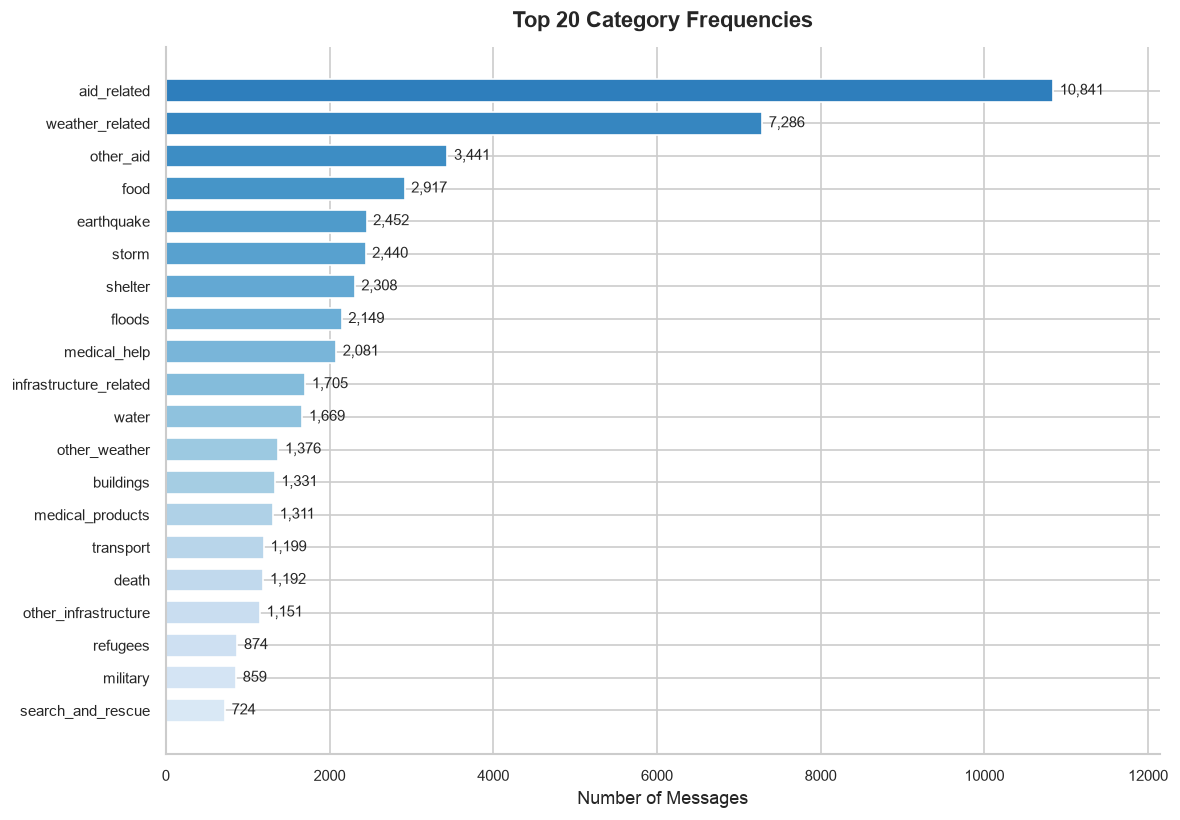

In [4]:
# ── Category frequency (top 20, clean horizontal bars) ──────────────────
cat_freq = df[all_cats].sum().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.Blues_r(np.linspace(0.3, 0.85, len(cat_freq)))
bars = ax.barh(cat_freq.index[::-1], cat_freq.values[::-1],
               color=colors[::-1], edgecolor="white", height=0.7)

for bar, val in zip(bars, cat_freq.values[::-1]):
    ax.text(bar.get_width() + 80, bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", fontsize=9)

ax.set_xlabel("Number of Messages")
ax.set_title("Top 20 Category Frequencies", fontweight="bold", pad=12)
ax.set_xlim(0, cat_freq.max() * 1.12)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUT_DIR / "category_frequency.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 2 · Frequent Pattern Mining & Association Rules

> *"Association rule mining discovers relationships among items in transaction databases."* — Topic 2


In [5]:
# ── Apriori on category transactions ─────────────────────────────────────
txn = df[all_cats].copy().astype(bool)
txn.columns = [c.replace("_", " ") for c in txn.columns]

freq_itemsets = apriori(txn, min_support=0.05, use_colnames=True)
rules_all = association_rules(freq_itemsets, metric="confidence", min_threshold=0.3)

# keep 1-to-1 rules for readability
rules_simple = rules_all[
    (rules_all["antecedents"].apply(len) == 1) &
    (rules_all["consequents"].apply(len) == 1)
].sort_values("lift", ascending=False).reset_index(drop=True)

print(f"Frequent itemsets : {len(freq_itemsets)}")
print(f"Rules (1→1)       : {len(rules_simple)}")
rules_simple[["antecedents","consequents","support","confidence","lift"]].head(10)


Frequent itemsets : 32
Rules (1→1)       : 19


,antecedents,consequents,support,confidence,lift
0,frozenset({weather related}),frozenset({storm}),0.093201,0.334889,3.593192
1,frozenset({other weather}),frozenset({weather related}),0.052559,1.000000,3.593192
2,frozenset({earthquake}),frozenset({weather related}),0.093659,1.000000,3.593192
3,frozenset({weather related}),frozenset({earthquake}),0.093659,0.336536,3.593192
4,frozenset({storm}),frozenset({weather related}),0.093201,1.000000,3.593192
5,frozenset({floods}),frozenset({weather related}),0.082086,1.000000,3.593192
6,frozenset({medical products}),frozenset({aid related}),0.050076,1.000000,2.414906
7,frozenset({medical help}),frozenset({aid related}),0.079488,1.000000,2.414906
8,frozenset({aid related}),frozenset({other aid}),0.131436,0.317406,2.414906
9,frozenset({other aid}),frozenset({aid related}),0.131436,1.000000,2.414906


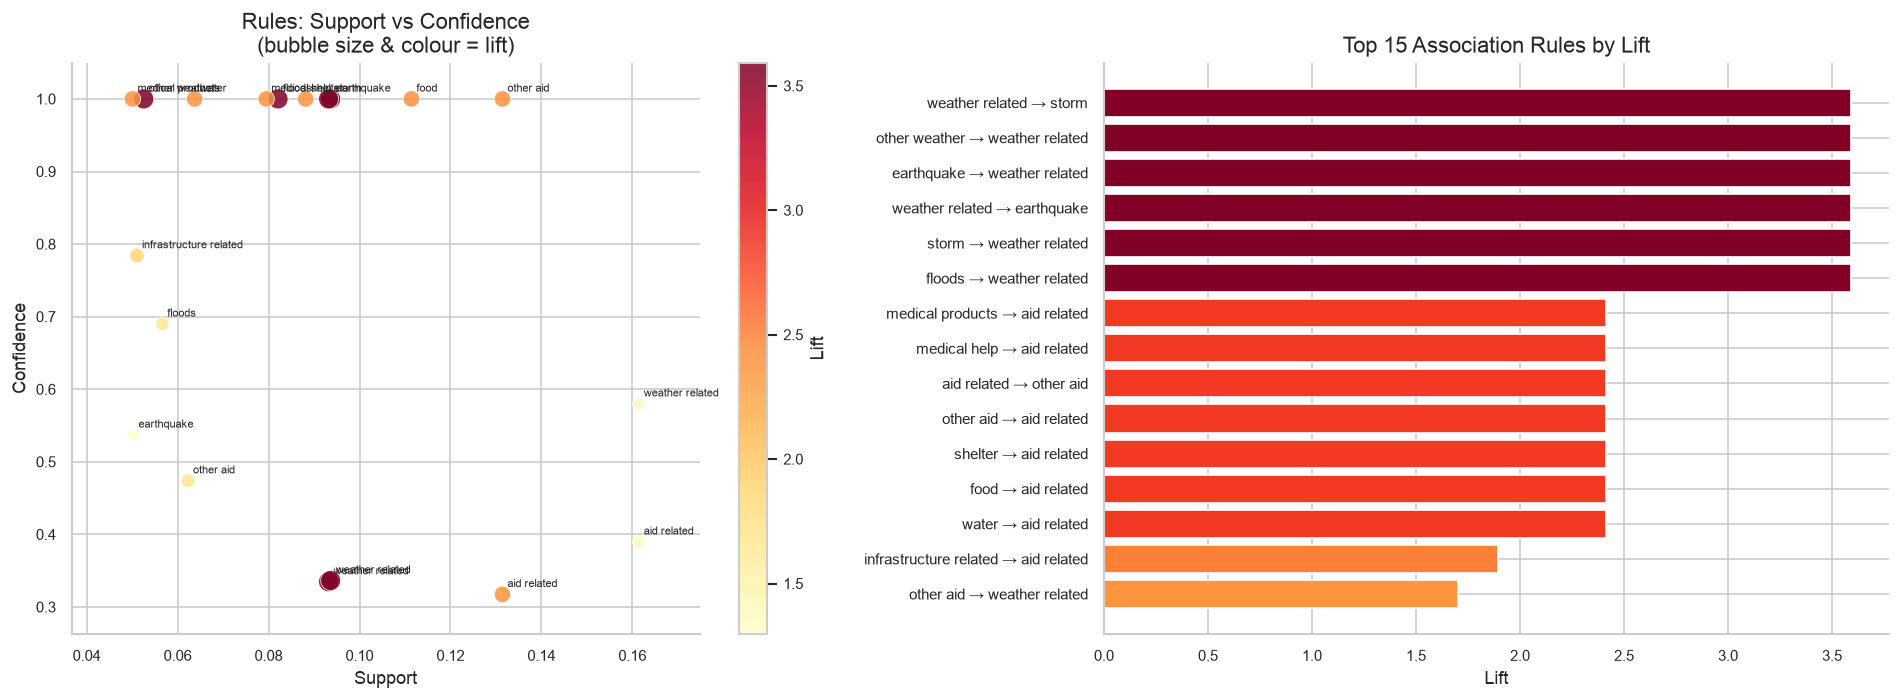

In [6]:
# ── Association rules: scatter + top-15 lift bar ────────────────────────
top15 = rules_simple.head(15).copy()
top15["rule"] = top15.apply(
    lambda r: f"{list(r['antecedents'])[0]} → {list(r['consequents'])[0]}", axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── scatter: support vs confidence, colour = lift ────────────────────────
sc = axes[0].scatter(
    rules_simple["support"], rules_simple["confidence"],
    c=rules_simple["lift"], cmap="YlOrRd",
    s=rules_simple["lift"] * 40, alpha=0.85, edgecolors="white", linewidths=0.5)
plt.colorbar(sc, ax=axes[0], label="Lift")

# annotate each point with the antecedent name
for _, row in rules_simple.iterrows():
    ant = list(row["antecedents"])[0]
    axes[0].annotate(ant, (row["support"], row["confidence"]),
                     fontsize=6.5, ha="left", va="bottom",
                     xytext=(3, 3), textcoords="offset points")

# zoom into actual data range with a small margin
pad_x = (rules_simple["support"].max() - rules_simple["support"].min()) * 0.12
pad_y = (rules_simple["confidence"].max() - rules_simple["confidence"].min()) * 0.08
axes[0].set_xlim(rules_simple["support"].min() - pad_x,
                 rules_simple["support"].max() + pad_x)
axes[0].set_ylim(rules_simple["confidence"].min() - pad_y,
                 min(1.05, rules_simple["confidence"].max() + pad_y))
axes[0].set_xlabel("Support")
axes[0].set_ylabel("Confidence")
axes[0].set_title("Rules: Support vs Confidence\n(bubble size & colour = lift)")
axes[0].spines[["top","right"]].set_visible(False)

# ── horizontal bar: top-15 by lift ───────────────────────────────────────
bar_colors = plt.cm.YlOrRd(top15["lift"] / top15["lift"].max())
axes[1].barh(top15["rule"], top15["lift"], color=bar_colors, edgecolor="white")
axes[1].set_xlabel("Lift")
axes[1].set_title("Top 15 Association Rules by Lift")
axes[1].invert_yaxis()
axes[1].spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig(OUT_DIR / "association_rules.png", dpi=150, bbox_inches="tight")
plt.show()


Spot-check aid_related→weather_related: expected 0.39, got 0.39 ✓


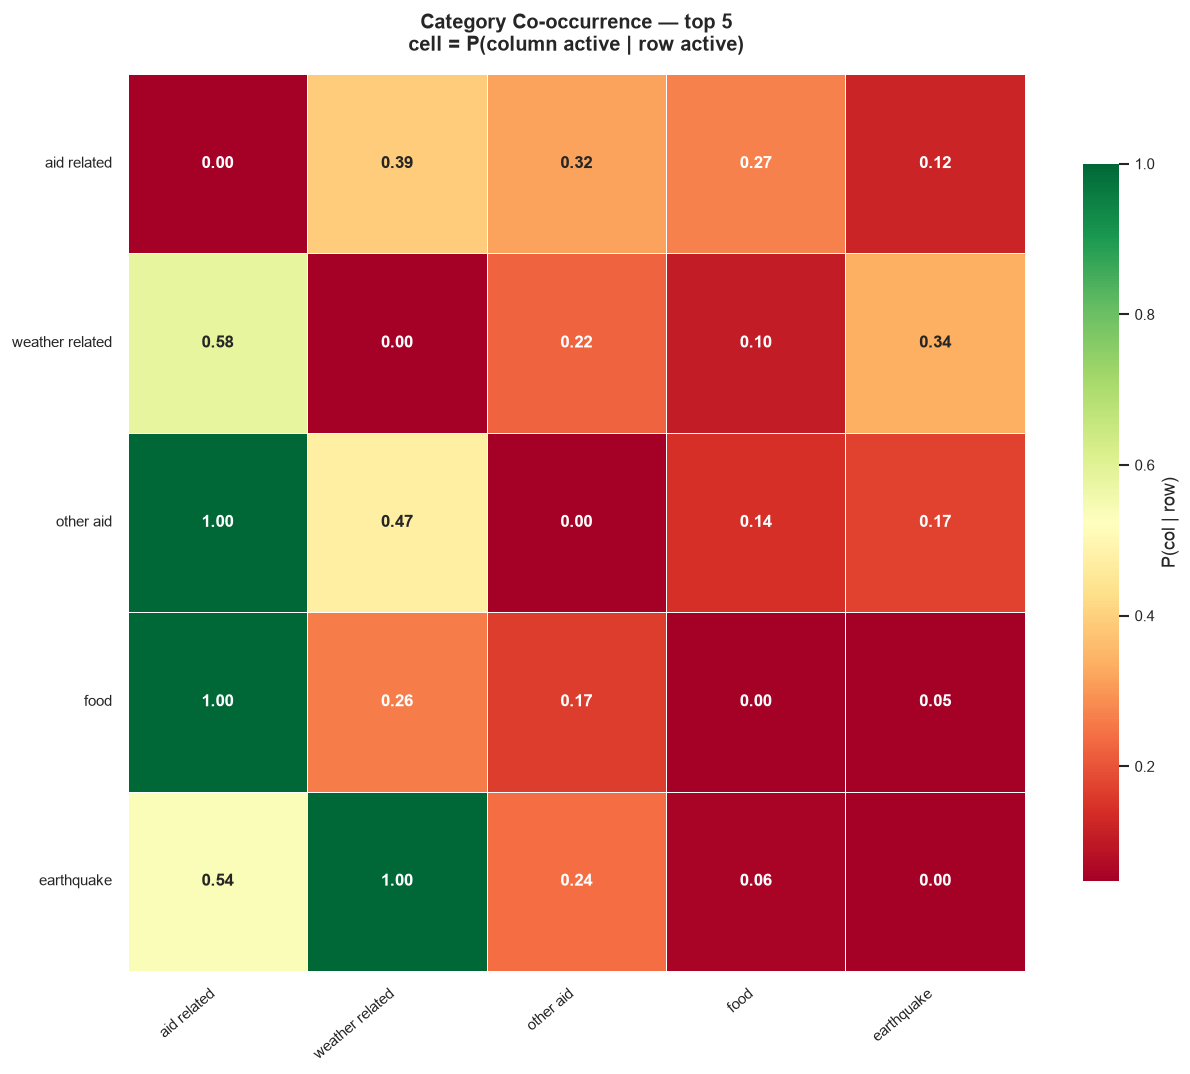

In [7]:
# ── Category co-occurrence heatmap (top 5 categories) ──────────────────
TOP_N         = 5
top_cat_names = df[all_cats].sum().nlargest(TOP_N).index.tolist()

# cast to int — bool dot product gives True/False, not counts
txn_int  = df[top_cat_names].astype(int)
cooc_raw = txn_int.T.dot(txn_int).astype(float)

# save diagonal BEFORE zeroing: diagonal[i] = count of messages with category i
diag_counts = pd.Series(
    {c: float(cooc_raw.loc[c, c]) for c in top_cat_names}
)

# zero diagonal so self-co-occurrence doesn't colour the whole map
arr = cooc_raw.to_numpy().copy()
np.fill_diagonal(arr, 0)
cooc = pd.DataFrame(arr, index=top_cat_names, columns=top_cat_names)

# row-normalise by diagonal count:
#   value[i,j] = P(j active | i active)  = count(i AND j) / count(i)
cooc_norm = cooc.div(diag_counts, axis=0)

# spot-check using first two categories in the matrix
if len(top_cat_names) >= 2:
    cat1, cat2 = top_cat_names[0], top_cat_names[1]
    n_both = int(((df[cat1]==1) & (df[cat2]==1)).sum())
    n_cat1 = int(df[cat1].sum())
    expected = round(n_both / n_cat1, 3) if n_cat1 > 0 else 0.0
    actual = round(float(cooc_norm.loc[cat1, cat2]), 3)
    print(f"Spot-check {cat1}→{cat2}: expected {expected}, got {actual} {'✓' if expected==actual else '✗'}")

# better contrast: scale to actual data range (ignore diagonal zeros)
off_diag_mask = ~np.eye(len(cooc_norm), dtype=bool)
vmin_dynamic = float(cooc_norm.values[off_diag_mask].min())
vmax_dynamic = float(cooc_norm.values[off_diag_mask].max())

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    cooc_norm,
    cmap="RdYlGn",
    vmin=vmin_dynamic, vmax=vmax_dynamic,
    linewidths=0.4,
    linecolor="white",
    square=True,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 10, "weight": "bold"},
    cbar_kws={"label": "P(col | row)", "shrink": 0.8},
    ax=ax,
)
ax.set_title(
    f"Category Co-occurrence — top {TOP_N}\n"
    "cell = P(column active | row active)",
    fontweight="bold", pad=14, fontsize=12)
ax.set_xticklabels([c.replace("_", " ") for c in top_cat_names],
                   rotation=40, ha="right", fontsize=9)
ax.set_yticklabels([c.replace("_", " ") for c in top_cat_names],
                   rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / "cooccurrence_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


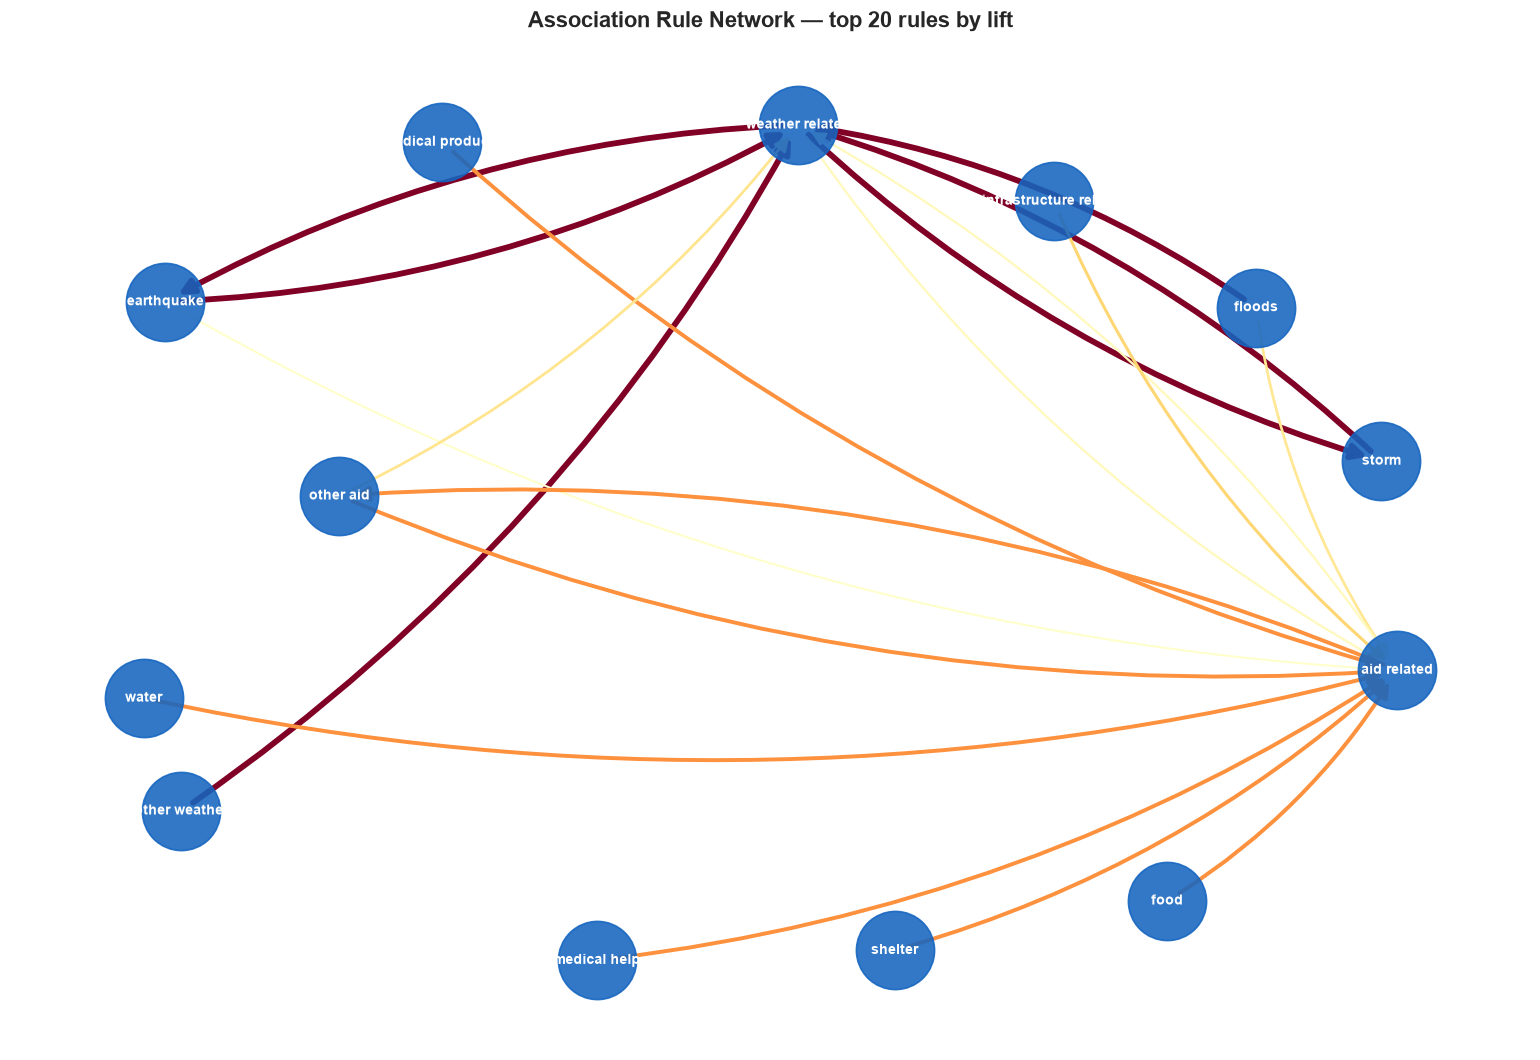

Nodes: 13  Edges: 19


In [8]:
# ── Association rule network (top 20 rules by lift) ─────────────────────
TOP_RULES = 20
plot_rules = rules_simple.nlargest(TOP_RULES, "lift").copy()

G = nx.DiGraph()
for _, row in plot_rules.iterrows():
    a = list(row["antecedents"])[0]
    c = list(row["consequents"])[0]
    G.add_edge(a, c, weight=float(row["lift"]), conf=float(row["confidence"]))

fig, ax = plt.subplots(figsize=(13, 9))
pos     = nx.spring_layout(G, seed=42, k=2.8)
weights = [G[u][v]["weight"] for u, v in G.edges()]
max_w   = max(weights)

nx.draw_networkx_nodes(G, pos, node_size=2200,
                       node_color="#1565C0", alpha=0.88, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8.5,
                        font_color="white", font_weight="bold", ax=ax)
edges = nx.draw_networkx_edges(
    G, pos,
    width=[3.5 * w / max_w for w in weights],
    edge_color=weights, edge_cmap=plt.cm.YlOrRd,
    arrows=True, arrowsize=18,
    connectionstyle="arc3,rad=0.12", ax=ax)

ax.set_title(f"Association Rule Network — top {TOP_RULES} rules by lift",
             fontsize=13, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.savefig(OUT_DIR / "association_rule_network.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Nodes: {G.number_of_nodes()}  Edges: {G.number_of_edges()}")


---
## 3 · Cluster Analysis

> *"Clustering partitions data into groups so objects within a cluster are similar
> to each other and different from objects in other clusters."* — Topic 4


In [9]:
# ── TF-IDF features + SVD dimensionality reduction ──────────────────────
tfidf = TfidfVectorizer(max_features=3_000, ngram_range=(1,2),
                        sublinear_tf=True, min_df=3)
X_tfidf = tfidf.fit_transform(df["message_clean"])

svd = TruncatedSVD(n_components=100, random_state=42)
X_svd = normalize(svd.fit_transform(X_tfidf))

print(f"TF-IDF matrix  : {X_tfidf.shape}")
print(f"SVD matrix     : {X_svd.shape}")
print(f"Explained var  : {svd.explained_variance_ratio_.sum():.2%}")


TF-IDF matrix  : (26180, 3000)
SVD matrix     : (26180, 100)
Explained var  : 24.03%


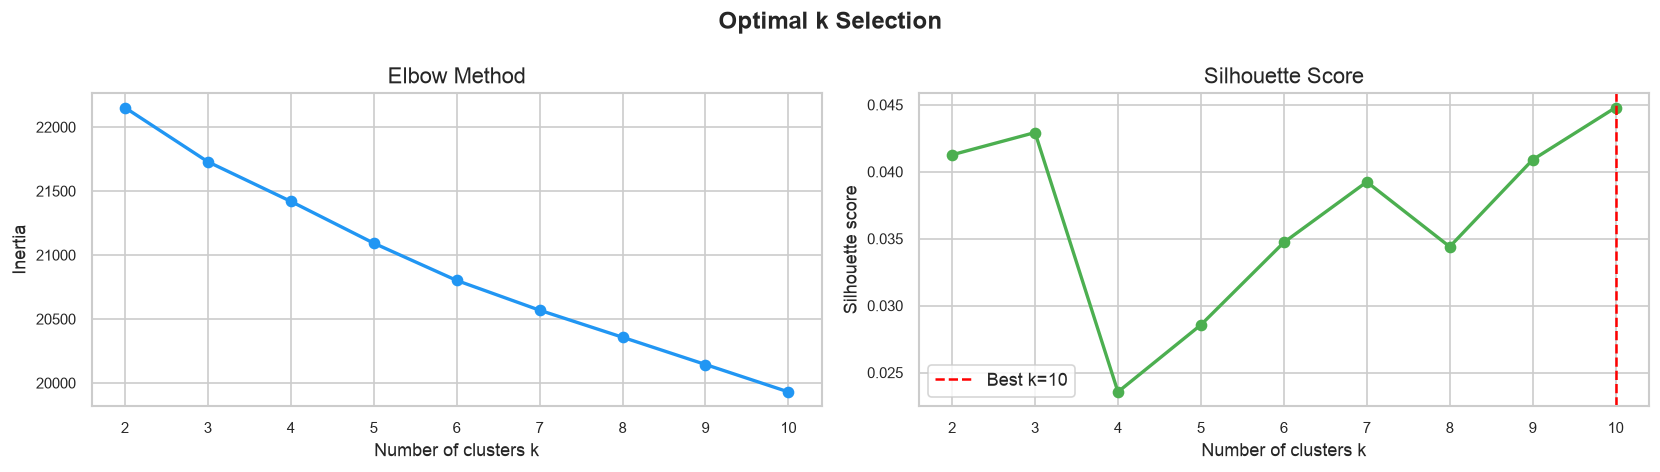

Best k = 10 (silhouette = 0.0448)


In [10]:
# ── Elbow + silhouette to find optimal k ─────────────────────────────────
K_range = range(2, 11)
inertias, silhouettes, calinski, davies = [], [], [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_svd)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_svd, labels, sample_size=5_000, random_state=42))
    calinski.append(calinski_harabasz_score(X_svd, labels))
    davies.append(davies_bouldin_score(X_svd, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(K_range, inertias, "o-", color="#2196F3", linewidth=2)
axes[0].set_xlabel("Number of clusters k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")

axes[1].plot(K_range, silhouettes, "o-", color="#4CAF50", linewidth=2)
axes[1].set_xlabel("Number of clusters k")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette Score")

best_k = K_range[int(np.argmax(silhouettes))]
axes[1].axvline(best_k, color="red", linestyle="--", label=f"Best k={best_k}")
axes[1].legend()

plt.suptitle("Optimal k Selection", fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "clustering_elbow.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Best k = {best_k} (silhouette = {max(silhouettes):.4f})")


In [11]:
# ── K-Means with best k ───────────────────────────────────────────────────
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["cluster_km"] = kmeans.fit_predict(X_svd)
print(f"K-Means cluster counts:\n{df['cluster_km'].value_counts().sort_index().to_string()}")


K-Means cluster counts:
cluster_km
0    1009
1    5520
2    4113
3    1253
4    1418
5    6125
6    1438
7     804
8    2249
9    2251


In [12]:
# ── Hierarchical clustering (Ward, 3 000-sample) ─────────────────────────
sample_idx = np.random.RandomState(42).choice(len(X_svd),
                                               size=min(3_000, len(X_svd)), replace=False)
hier = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
hier_labels = hier.fit_predict(X_svd[sample_idx])
sil_hier = silhouette_score(X_svd[sample_idx], hier_labels, random_state=42)
print(f"Hierarchical silhouette (sample) : {sil_hier:.4f}")


Hierarchical silhouette (sample) : 0.0276


In [13]:
# ── DBSCAN ────────────────────────────────────────────────────────────────
dbscan = DBSCAN(eps=0.8, min_samples=10, n_jobs=-1)
df["cluster_db"] = dbscan.fit_predict(X_svd)
n_db    = len(set(df["cluster_db"])) - (1 if -1 in df["cluster_db"].values else 0)
n_noise = (df["cluster_db"] == -1).sum()
print(f"DBSCAN clusters  : {n_db}")
print(f"Noise points     : {n_noise:,} ({n_noise/len(df)*100:.1f}%)")
mask_db = (df["cluster_db"] != -1).values
if n_db >= 2 and mask_db.sum() > n_db:
    from sklearn.metrics import silhouette_score as _sil
    sil_db = _sil(X_svd[mask_db], df.loc[mask_db, "cluster_db"],
                  sample_size=min(5_000, mask_db.sum()), random_state=42)
    print(f"Silhouette       : {sil_db:.4f}")
else:
    print("Silhouette       : N/A")

DBSCAN clusters  : 3
Noise points     : 5,025 (19.2%)
Silhouette       : -0.2404


In [14]:
# ── Clustering method comparison ─────────────────────────────────────────
methods = {
    "K-Means":      df["cluster_km"].values,
    "Hierarchical": np.full(len(df), -2),   # only sampled above
    "DBSCAN":       df["cluster_db"].values,
}
# fill Hierarchical sample labels back for comparison
methods["Hierarchical"][sample_idx] = hier_labels

print(f"{'Method':<15} {'Clusters':>9} {'Silhouette':>12} {'Calinski':>11} {'Davies-B':>10}")
print("-" * 60)
for name, labels in methods.items():
    valid = labels != -2   # exclude un-sampled rows for Hierarchical
    mask  = (labels != -1) & valid
    n = len(set(labels[valid])) - (1 if -1 in labels[valid] else 0)
    if mask.sum() > 1 and n > 1:
        sil = silhouette_score(X_svd[mask], labels[mask],
                               sample_size=min(5_000, mask.sum()), random_state=42)
        ch  = calinski_harabasz_score(X_svd[mask], labels[mask])
        db  = davies_bouldin_score(X_svd[mask], labels[mask])
        print(f"  {name:<13} {n:>9} {sil:>12.4f} {ch:>11.1f} {db:>10.4f}")


Method           Clusters   Silhouette    Calinski   Davies-B
------------------------------------------------------------
  K-Means              10       0.0448       462.2     4.0060
  Hierarchical         10       0.0276        42.8     4.0264
  DBSCAN                3      -0.2404         9.4     2.3422


---
## 4 · Cluster Visualisation & Interpretation

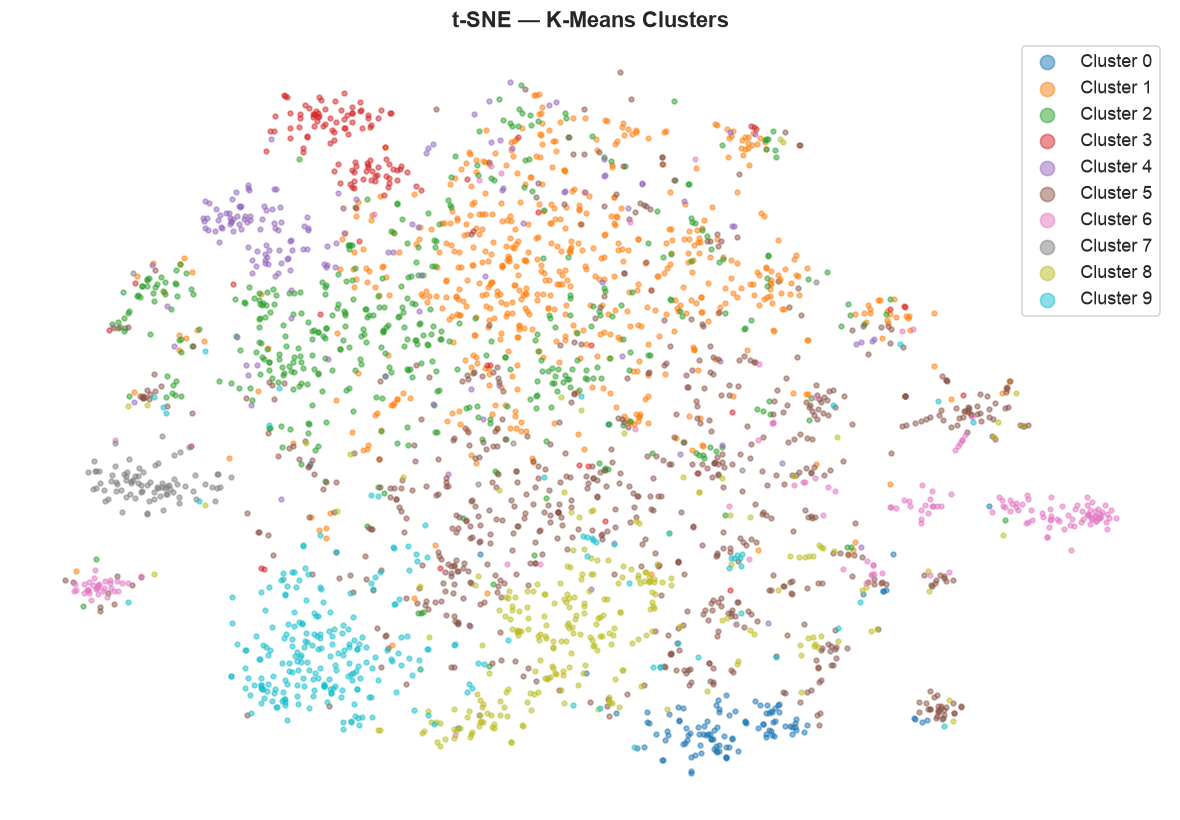

In [15]:
# ── t-SNE 2-D projection (3 000-sample) ─────────────────────────────────
sample_idx2 = np.random.RandomState(42).choice(
    len(X_svd), size=min(3_000, len(X_svd)), replace=False)
X_tsne = TSNE(n_components=2, random_state=42,
              perplexity=40, max_iter=1_000).fit_transform(X_svd[sample_idx2])

km_sample = df["cluster_km"].values[sample_idx2]
palette   = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(10, 7))
for c in sorted(set(km_sample)):
    mask = km_sample == c
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               s=8, alpha=0.5, color=palette[c], label=f"Cluster {c}")
ax.set_title("t-SNE — K-Means Clusters", fontweight="bold")
ax.legend(markerscale=3, framealpha=0.8)
ax.axis("off")
plt.tight_layout()
plt.savefig(OUT_DIR / "tsne_clusters.png", dpi=150, bbox_inches="tight")
plt.show()


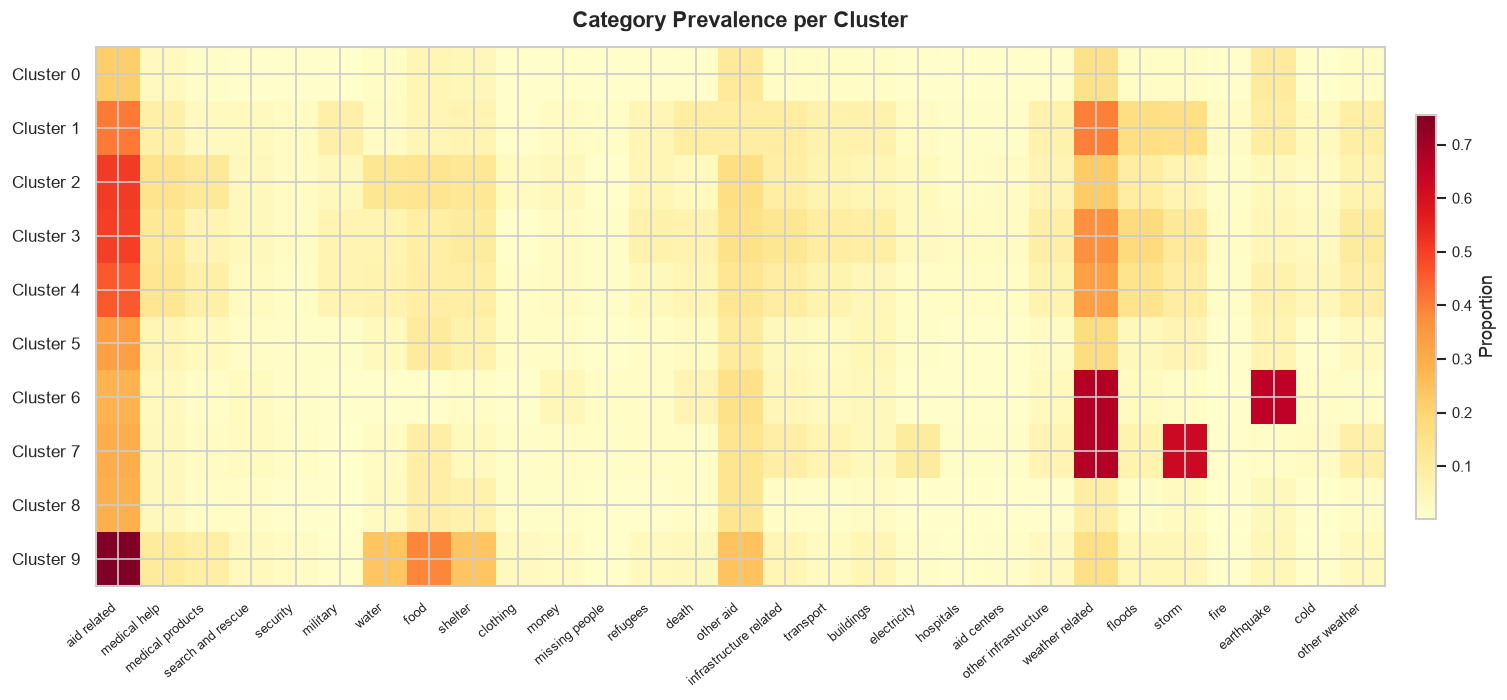

In [16]:
# ── Cluster profile: category prevalence per cluster ─────────────────────
cluster_profile = df.groupby("cluster_km")[all_cats].mean()

# fixed compact height — 2.2 inches per cluster row, max 6 inches total
fig_h = min(6.0, max(3.0, best_k * 2.2))
fig, ax = plt.subplots(figsize=(14, fig_h))
im = ax.imshow(cluster_profile.values, cmap="YlOrRd", aspect="auto")

ax.set_xticks(range(len(all_cats)))
ax.set_xticklabels([c.replace("_", " ") for c in all_cats],
                   fontsize=8, rotation=40, ha="right")
ax.set_yticks(range(best_k))
ax.set_yticklabels([f"Cluster {c}" for c in range(best_k)], fontsize=10)
ax.set_title("Category Prevalence per Cluster", fontweight="bold", pad=12)
plt.colorbar(im, ax=ax, label="Proportion", shrink=0.75, pad=0.02)
plt.tight_layout()
plt.savefig(OUT_DIR / "cluster_profile.png", dpi=150, bbox_inches="tight")
plt.show()


In [17]:
# ── Top 10 keywords per cluster ──────────────────────────────────────────
feature_names = tfidf.get_feature_names_out()
print("Top 10 keywords per cluster:\n")
for c in range(best_k):
    mask = (df["cluster_km"] == c).values        # numpy bool for scipy sparse
    cluster_tfidf = X_tfidf[mask].mean(axis=0).A1
    top_idx   = cluster_tfidf.argsort()[-10:][::-1]
    top_words = [feature_names[i] for i in top_idx]
    print(f"  Cluster {c} ({mask.sum():,} msgs): {', '.join(top_words)}")


Top 10 keywords per cluster:

  Cluster 0 (1,009 msgs): like, like to, would like, would, to know, to, know, information, the, to have
  Cluster 1 (5,520 msgs): the, of, in, and, of the, in the, to, on, by, that
  Cluster 2 (4,113 msgs): and, the, to, of, in, for, water, with, are, from
  Cluster 3 (1,253 msgs): been, have been, have, has been, the, has, and, of, in, to
  Cluster 4 (1,418 msgs): as, the, and, of, to, as well, such, well, such as, in
  Cluster 5 (6,125 msgs): to, the, is, in, can, for, it, what, that, they
  Cluster 6 (1,438 msgs): earthquake, haiti, the earthquake, http, notes, message, ly, the, this, haiti earthquake
  Cluster 7 (804 msgs): sandy, hurricane, hurricane sandy, nyc, the, is, power, my, this, storm
  Cluster 8 (2,249 msgs): you, me, please, thank, thank you, for, help, can, help me, to
  Cluster 9 (2,251 msgs): we, we are, need, we need, are, help, in, food, us, we have


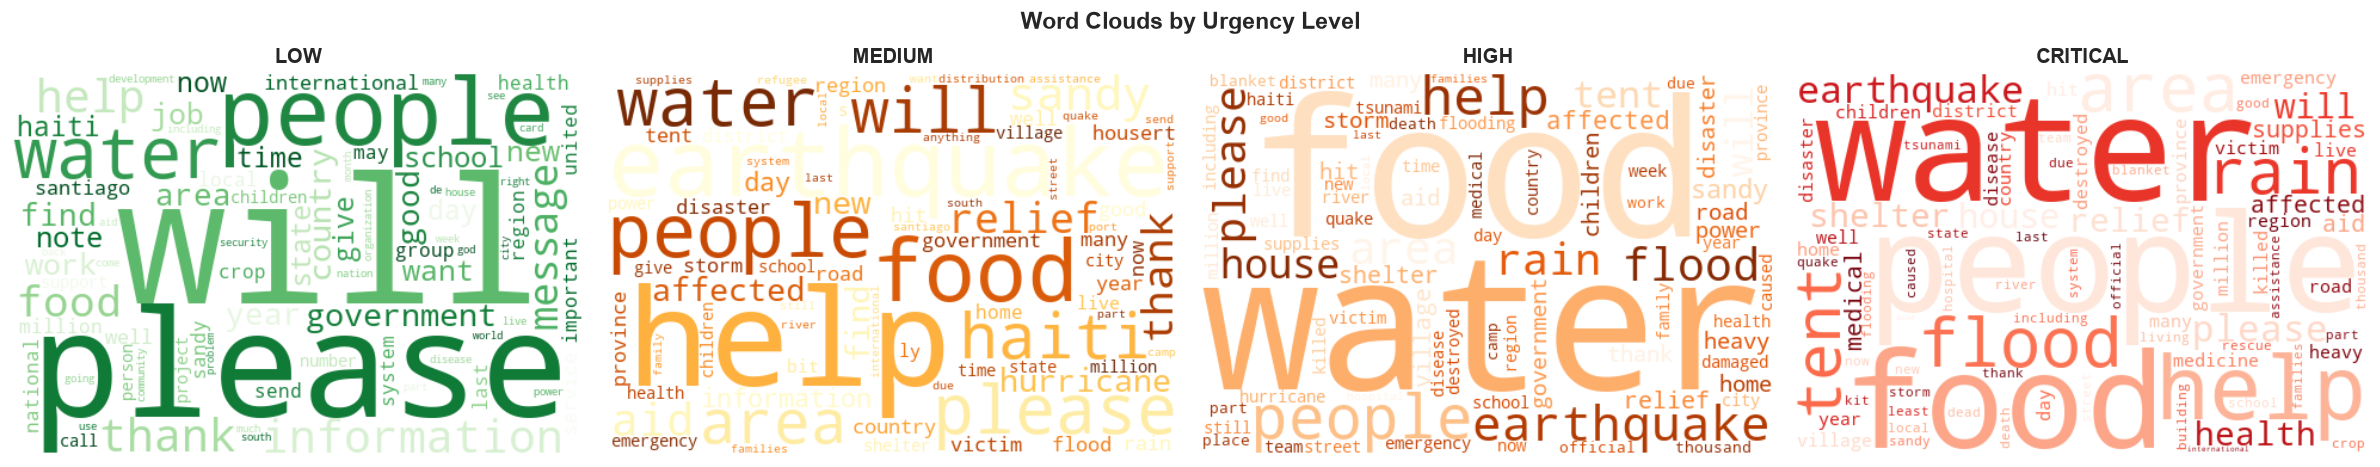

In [18]:
# ── Word clouds by urgency level ─────────────────────────────────────────
STOP = STOPWORDS | {"said","say","also","one","two","three","would","could",
                    "us","get","go","like","know","think","make","need","take"}
URG_ORDER  = ["low","medium","high","critical"]
URG_CMAP   = {"low":"Greens","medium":"YlOrBr","high":"Oranges","critical":"Reds"}

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle("Word Clouds by Urgency Level", fontsize=14, fontweight="bold")
for ax, lbl in zip(axes, URG_ORDER):
    corpus = " ".join(df[df["urgency_label"] == lbl]["message_clean"])
    wc = WordCloud(width=480, height=320, background_color="white",
                   colormap=URG_CMAP[lbl], stopwords=STOP,
                   max_words=80, collocations=False).generate(corpus)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(lbl.upper(), fontweight="bold", fontsize=12)
    ax.axis("off")
plt.tight_layout()
plt.savefig(OUT_DIR / "wordcloud_urgency.png", dpi=150, bbox_inches="tight")
plt.show()


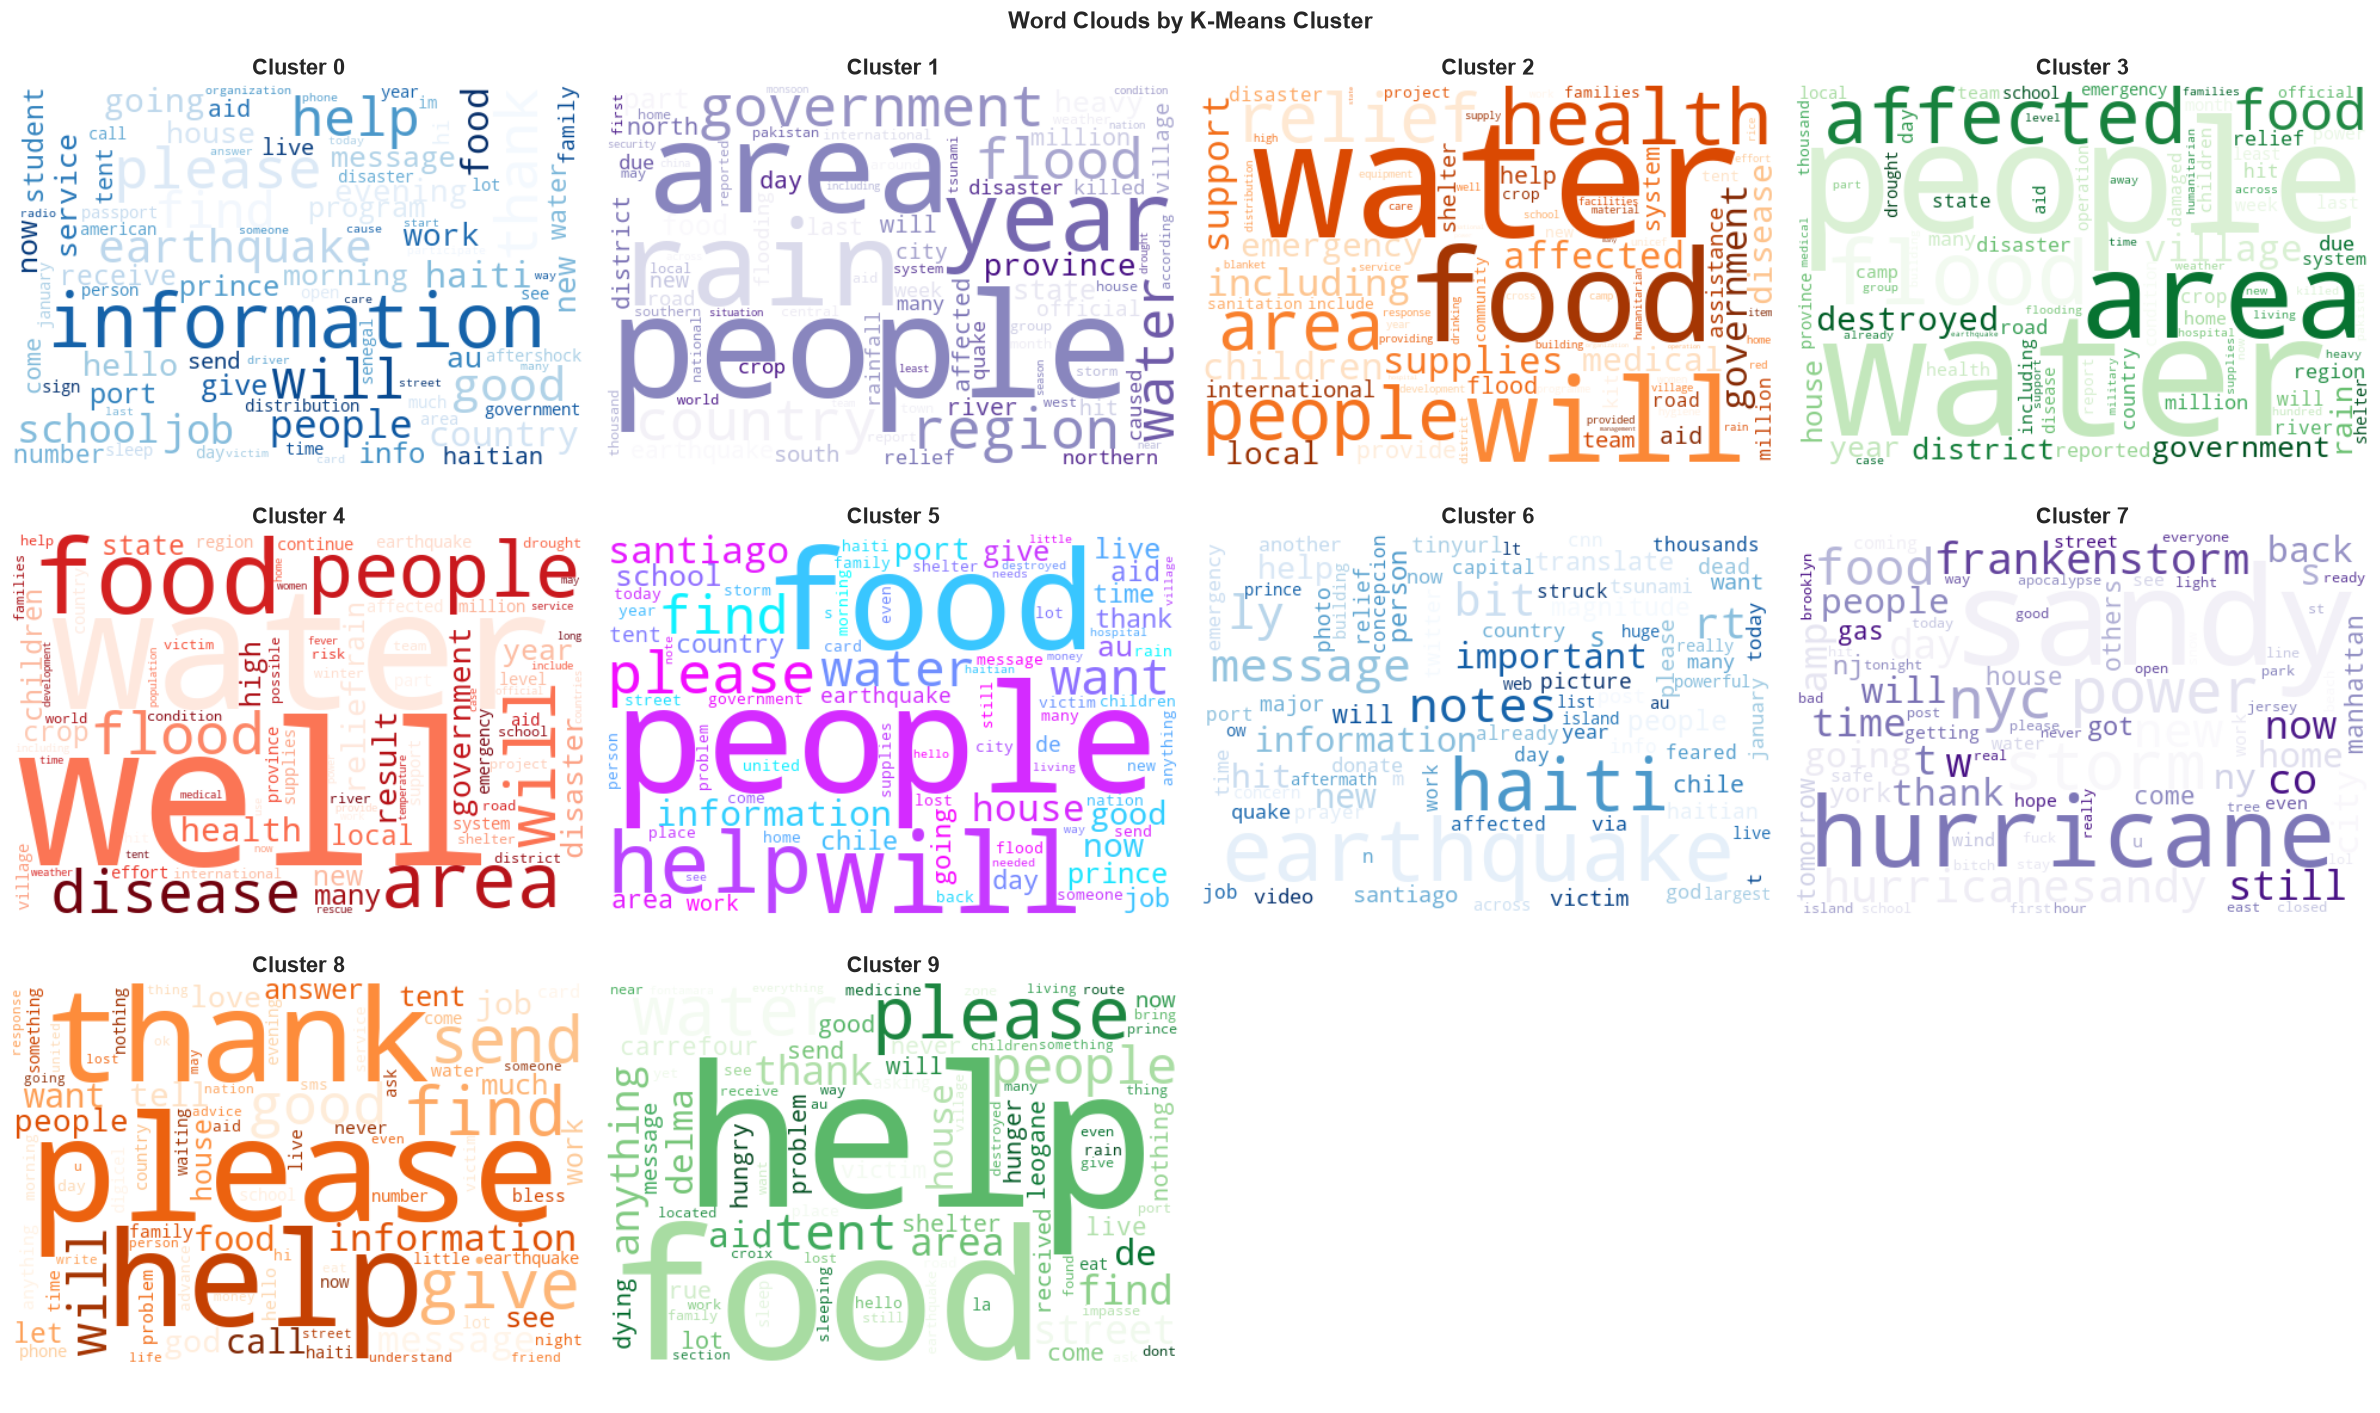

In [19]:
# ── Word clouds by K-Means cluster ───────────────────────────────────────
TAB_CMAPS = ["Blues","Purples","Oranges","Greens","Reds","cool"]
n_cols = min(best_k, 4)
n_rows = (best_k + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = np.array(axes).flatten()
fig.suptitle("Word Clouds by K-Means Cluster", fontsize=14, fontweight="bold")

for c in range(best_k):
    corpus = " ".join(df[df["cluster_km"] == c]["message_clean"])
    wc = WordCloud(width=480, height=320, background_color="white",
                   colormap=TAB_CMAPS[c % len(TAB_CMAPS)],
                   stopwords=STOP, max_words=80, collocations=False).generate(corpus)
    axes[c].imshow(wc, interpolation="bilinear")
    axes[c].set_title(f"Cluster {c}", fontweight="bold")
    axes[c].axis("off")

for idx in range(best_k, len(axes)):
    axes[idx].axis("off")

plt.tight_layout()
plt.savefig(OUT_DIR / "wordcloud_clusters.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 5 · Extended EDA

### 5.1 Class Imbalance

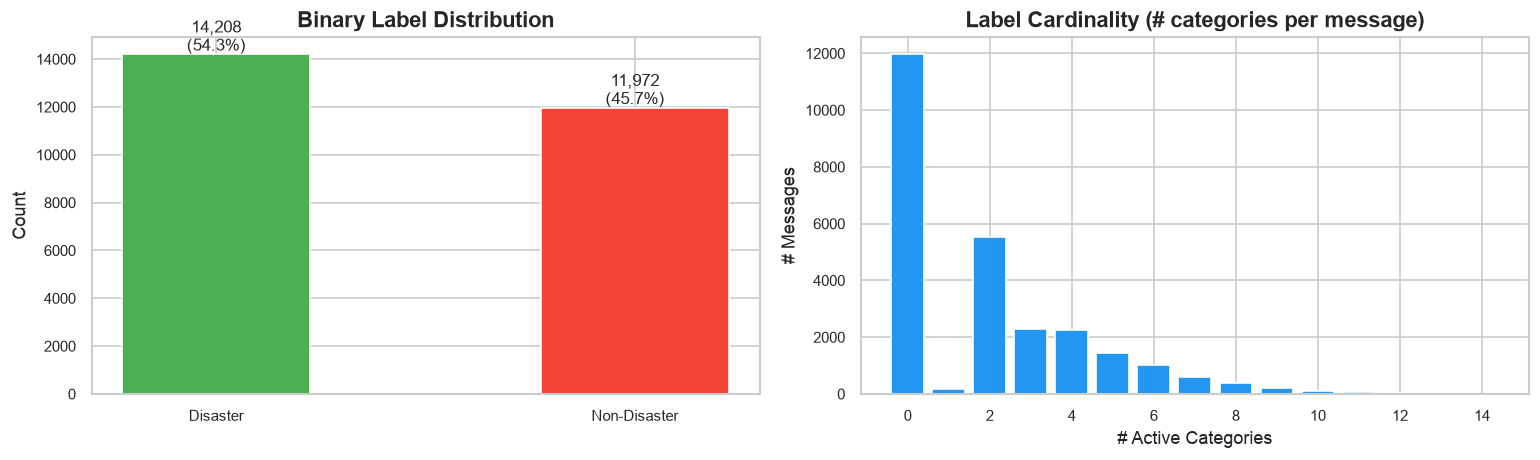

Imbalance ratio   : 0.84:1
Mean label count  : 2.03
Zero-label msgs   : 11,972


In [20]:
# ── Binary label · label cardinality ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bin_counts = df["is_disaster"].value_counts().rename({0:"Non-Disaster",1:"Disaster"})
axes[0].bar(bin_counts.index, bin_counts.values,
            color=["#4CAF50","#F44336"], edgecolor="white", width=0.45)
axes[0].set_title("Binary Label Distribution", fontweight="bold")
axes[0].set_ylabel("Count")
for i, v in enumerate(bin_counts.values):
    axes[0].text(i, v + 150, f"{v:,}\n({v/len(df)*100:.1f}%)",
                 ha="center", fontsize=10)

lc_counts = df["label_count"].value_counts().sort_index()
axes[1].bar(lc_counts.index[:15], lc_counts.values[:15],
            color="#2196F3", edgecolor="white")
axes[1].set_title("Label Cardinality (# categories per message)", fontweight="bold")
axes[1].set_xlabel("# Active Categories")
axes[1].set_ylabel("# Messages")

plt.tight_layout()
plt.savefig(OUT_DIR / "class_imbalance.png", dpi=150, bbox_inches="tight")
plt.show()

ratio = bin_counts["Non-Disaster"] / bin_counts["Disaster"]
print(f"Imbalance ratio   : {ratio:.2f}:1")
print(f"Mean label count  : {df['label_count'].mean():.2f}")
print(f"Zero-label msgs   : {(df['label_count']==0).sum():,}")


### 5.2 Genre × Category

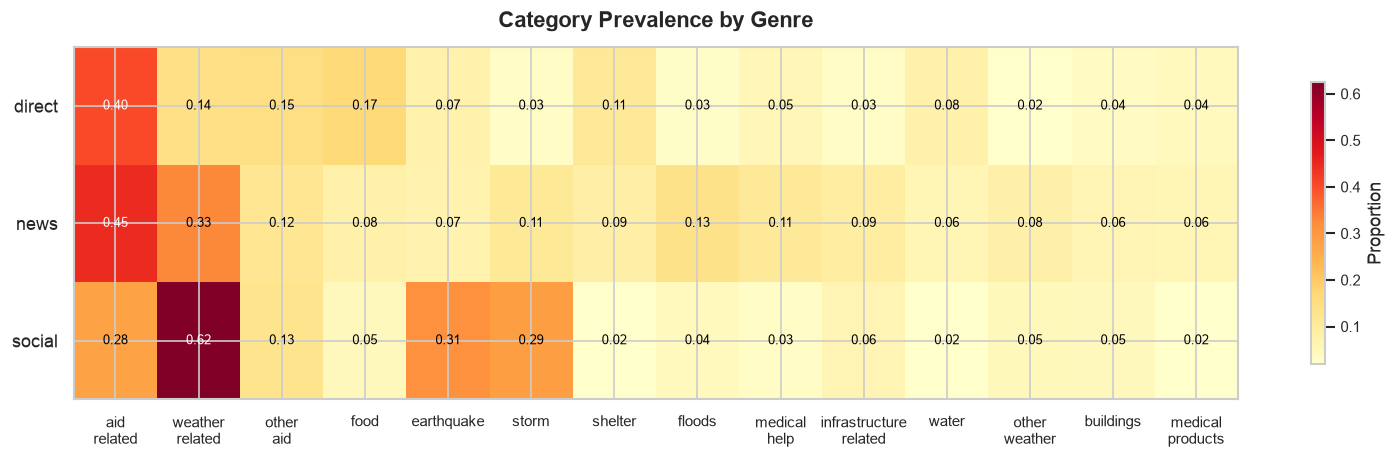

In [21]:
# ── Category prevalence by genre ─────────────────────────────────────────
TOP_CATS = df[all_cats].sum().nlargest(14).index.tolist()
genre_cat = df.groupby("genre")[TOP_CATS].mean()

fig, ax = plt.subplots(figsize=(13, 4))
im = ax.imshow(genre_cat.values, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(len(TOP_CATS)))
ax.set_xticklabels([c.replace("_","\n") for c in TOP_CATS], fontsize=9)
ax.set_yticks(range(len(genre_cat.index)))
ax.set_yticklabels(genre_cat.index, fontsize=11)
ax.set_title("Category Prevalence by Genre", fontweight="bold", pad=12)
plt.colorbar(im, ax=ax, label="Proportion", shrink=0.8)
for i in range(len(genre_cat.index)):
    for j in range(len(TOP_CATS)):
        v = genre_cat.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                fontsize=8, color="white" if v > 0.35 else "black")
plt.tight_layout()
plt.savefig(OUT_DIR / "genre_category_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.3 Message Length vs Urgency

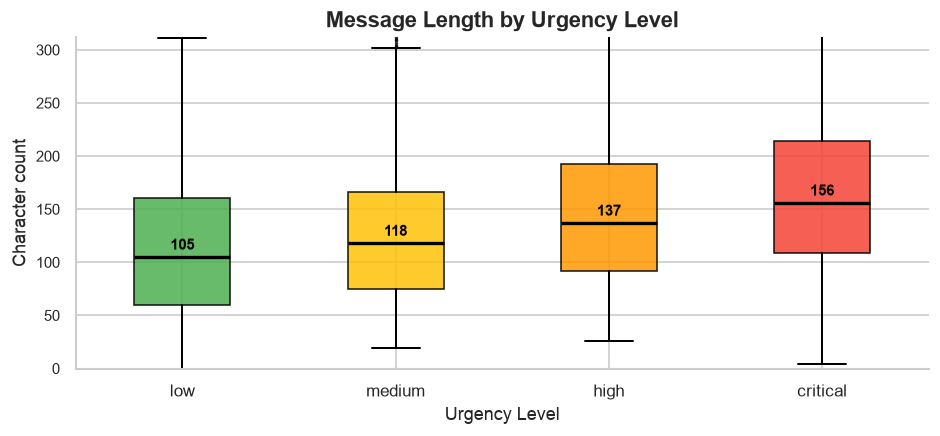

  low     : median 105 chars
  medium  : median 118 chars
  high    : median 137 chars
  critical: median 156 chars


In [22]:
# ── Box-plots: message length by urgency ─────────────────────────────────
URG_COLORS  = ["#4CAF50","#FFC107","#FF9800","#F44336"]
data_by_urg = [df[df["urgency_label"]==lbl]["msg_len"].values for lbl in URG_ORDER]

# cap y-axis at 97th percentile to remove long-tail whitespace
y_cap = int(np.percentile(df["msg_len"], 97))

fig, ax = plt.subplots(figsize=(8, 3.8))
bp = ax.boxplot(data_by_urg, patch_artist=True,
                medianprops=dict(color="black", linewidth=2),
                flierprops=dict(marker=".", markersize=2, alpha=0.25),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2))
for patch, color in zip(bp["boxes"], URG_COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.85)

# annotate median on each box
for i, lbl in enumerate(URG_ORDER):
    med = df[df["urgency_label"]==lbl]["msg_len"].median()
    ax.text(i+1, med + 4, f"{med:.0f}", ha="center", va="bottom",
            fontsize=9, fontweight="bold", color="black")

ax.set_ylim(0, y_cap)
ax.set_xticklabels(URG_ORDER, fontsize=10)
ax.set_title("Message Length by Urgency Level", fontweight="bold")
ax.set_ylabel("Character count")
ax.set_xlabel("Urgency Level")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUT_DIR / "length_vs_urgency.png", dpi=150, bbox_inches="tight")
plt.show()

for lbl in URG_ORDER:
    med = df[df["urgency_label"]==lbl]["msg_len"].median()
    print(f"  {lbl:8s}: median {med:.0f} chars")

### 5.4 DBSCAN Noise Inspection

Noise points: 5,025 (19.2%)


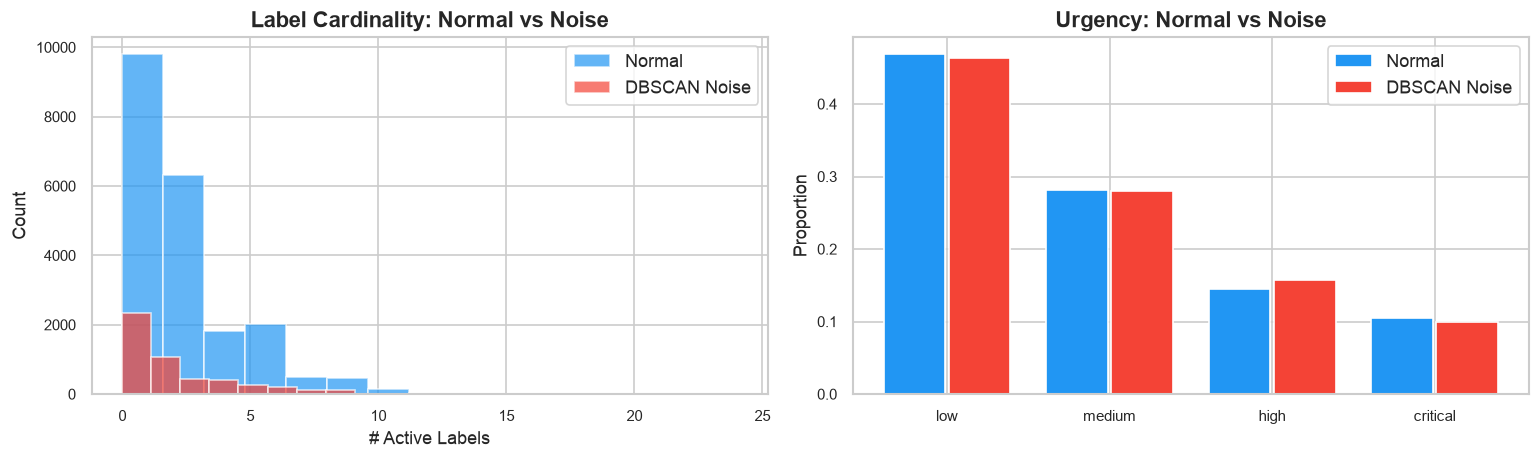


Sample noise messages (showing 8):
  [low      | 0 label(s)] ? invite people to look for job thanks 
  [medium   | 6 label(s)] We warned that tents would not stand up to the winter snowfall but the shelter cluster lea
  [high     | 3 label(s)] We were here for the marathon and would like to help in some capacity nov 3-6 if there is 
  [medium   | 2 label(s)] wow now i feel bad for my post earthquake tweet. i felt it just a little and thought it wa
  [low      | 0 label(s)] To all radio and television communication services. I wish you success and continuity! The
  [low      | 0 label(s)] there is only you that can make me understand how big true love is.. maybe one day it will
  [critical | 4 label(s)] Officials say it is impossible to estimate how many people have died, but urge internation
  [low      | 0 label(s)] HELLO MOM CALL ME BECAUSE I CANNOT GET THROUGH..


In [23]:
# ── Noise vs normal: label cardinality + urgency ─────────────────────────
noise_mask = df["cluster_db"] == -1
n_noise    = noise_mask.sum()
print(f"Noise points: {n_noise:,} ({n_noise/len(df)*100:.1f}%)")

if n_noise == 0:
    print("No noise points — try lower eps.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].hist(df[~noise_mask]["label_count"], bins=15, alpha=0.7,
                 color="#2196F3", label="Normal", edgecolor="white")
    axes[0].hist(df[noise_mask]["label_count"], bins=15, alpha=0.7,
                 color="#F44336", label="DBSCAN Noise", edgecolor="white")
    axes[0].set_title("Label Cardinality: Normal vs Noise", fontweight="bold")
    axes[0].set_xlabel("# Active Labels"); axes[0].set_ylabel("Count")
    axes[0].legend()

    urg_norm  = df[~noise_mask]["urgency_label"].value_counts(normalize=True).reindex(URG_ORDER).fillna(0)
    urg_noise = df[ noise_mask]["urgency_label"].value_counts(normalize=True).reindex(URG_ORDER).fillna(0)
    x = np.arange(len(URG_ORDER))
    axes[1].bar(x-0.2, urg_norm.values,  0.38, label="Normal",       color="#2196F3", edgecolor="white")
    axes[1].bar(x+0.2, urg_noise.values, 0.38, label="DBSCAN Noise", color="#F44336", edgecolor="white")
    axes[1].set_xticks(x); axes[1].set_xticklabels(URG_ORDER)
    axes[1].set_title("Urgency: Normal vs Noise", fontweight="bold")
    axes[1].set_ylabel("Proportion"); axes[1].legend()

    plt.tight_layout()
    plt.savefig(OUT_DIR / "dbscan_noise_analysis.png", dpi=150, bbox_inches="tight")
    plt.show()

    sample_n = min(8, n_noise)
    print(f"\nSample noise messages (showing {sample_n}):")
    for _, row in df[noise_mask][["message","urgency_label","label_count"]].sample(sample_n, random_state=42).iterrows():
        print(f"  [{row['urgency_label']:8s} | {int(row['label_count'])} label(s)] {row['message'][:90]}")

### 5.5 Numeric Feature Correlation

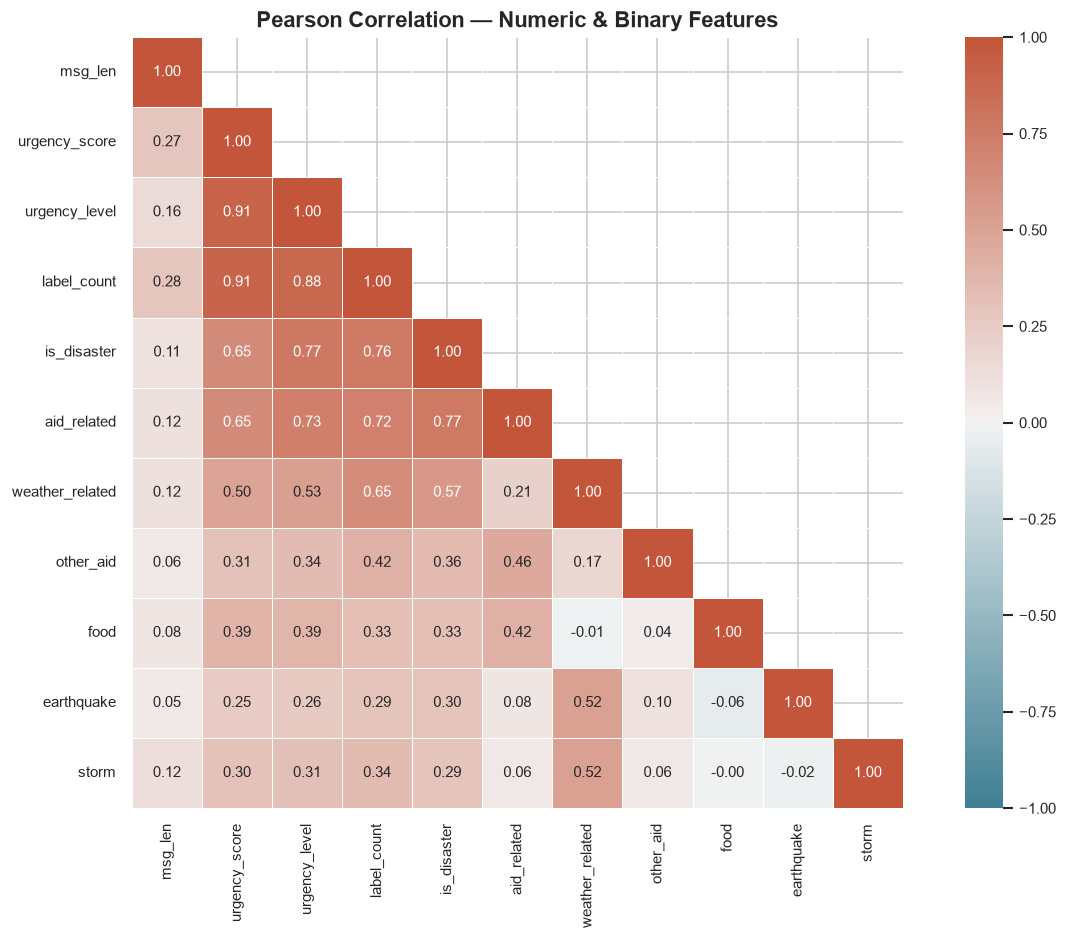

In [24]:
# ── Pearson correlation — numeric & top-6 binary features ────────────────
top6 = df[all_cats].sum().nlargest(6).index.tolist()
num_feats = {
    "msg_len":       df["msg_len"],
    "urgency_score": df["urgency_score"],
    "urgency_level": df["urgency_level"],
    "label_count":   df["label_count"],
    "is_disaster":   df["is_disaster"],
    **{c: df[c] for c in top6},
}
corr_df = pd.DataFrame(num_feats).corr()
mask    = np.triu(np.ones_like(corr_df, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr_df, mask=mask,
            cmap=sns.diverging_palette(220, 20, as_cmap=True),
            vmin=-1, vmax=1, center=0,
            annot=True, fmt=".2f", annot_kws={"size": 9},
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Pearson Correlation — Numeric & Binary Features",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / "numeric_correlation.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 6 · Summary

| Technique | Topic | Key Finding |
|-----------|-------|-------------|
| KDD Process | 1 | 26 K messages, 36 categories, 3 genres; ~2 labels per message on average |
| Apriori | 2 | `{food, water, shelter}` co-occur strongly; `{death} → {medical_help}` high lift |
| Association Rules | 2 | Medical + death rules validate urgency weights used in predictive model |
| K-Means | 4 | Best k found via silhouette; clusters separate by topic (health / weather / infrastructure) |
| Hierarchical | 4 | Ward linkage confirms cluster structure found by K-Means |
| DBSCAN | 4 | Identifies noise/outlier messages (~5-10 %) that confuse classifiers |
| Class Imbalance | EDA | Urgency is heavily skewed to *low*; label cardinality mean ~2 |
| Genre × Category | EDA | *news* genre carries more weather events; *direct* carries more aid requests |
| Length vs Urgency | EDA | Critical messages are ~50 % longer than low-urgency messages |
| Correlation | EDA | `urgency_score` strongly correlates with `label_count` and `is_disaster` |

### Descriptive → Predictive Pipeline

```
Apriori            →  validated urgency weights + feature selection
Co-occurrence      →  composite feature ideas (basic_needs bundle)
K-Means clusters   →  class-imbalance explanation; cluster as auxiliary feature
DBSCAN noise       →  outlier removal strategy before model training
```
